# Статическая оценка (ρ₁, ρ₂) по задержкам дыхания — §6.1

Читает метки из `timestamps/` (их строит `08_Скетч_разметки.ipynb`) и для каждого испытуемого:

1. собирает кривые зондирования `Z(L)` на задержках вдоха и выдоха (медианы плато — уже лежат в метках);
2. **основная оценка** — совместный МНК (ур. 12) с общим ρ₁, h фиксировано из КТ; плюс контрольный фит со свободным h (диагностика h_эфф vs h_КТ, §3.3);
3. **проверка** — облако пересечений (ρ₁,ρ₂) и его **взвешенный** центроид `w=sin²θ` (ур. 13);
4. диагностика применимости — угловой спред градиентов и FoM (§2.4): предсказание «у Георга ≈4× хуже».

Терминология: «обратная задача». h_КТ: Ник 15 мм, Георгий 40 мм.

In [1]:
# @title Импорты, модель, производные
import os, json, glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, least_squares
%matplotlib inline

TS_DIR = os.path.join(os.getcwd(), "timestamps")
NTERMS = 400

def Z_model(rho1, rho2, h, a, b, N=NTERMS):
    k = (rho2-rho1)/(rho1+rho2); d1, d2 = a-b, a+b; i = np.arange(1, N+1)
    G1 = 1/np.sqrt(d1**2 + (2*i*h)**2); G2 = 1/np.sqrt(d2**2 + (2*i*h)**2)
    return rho1/np.pi*(1/d1 - 1/d2) + 2*rho1/np.pi*np.sum(k**i*(G1-G2))

def _T(rho1, rho2, h, a, b, N=NTERMS):
    k = (rho2-rho1)/(rho1+rho2); d1, d2 = a-b, a+b; i = np.arange(1, N+1)
    dG = 1/np.sqrt(d1**2+(2*i*h)**2) - 1/np.sqrt(d2**2+(2*i*h)**2)
    return np.sum(i*k**(i-1)*dG)

def dZ_drho2(r1, r2, h, a, b): return 4*r1**2/(np.pi*(r1+r2)**2)*_T(r1, r2, h, a, b)
def dZ_drho1(r1, r2, h, a, b): return Z_model(r1, r2, h, a, b)/r1 - 4*r1*r2/(np.pi*(r1+r2)**2)*_T(r1, r2, h, a, b)
def rho_app(Z, a, b): return Z*np.pi*(a**2 - b**2)/(2*b)
def ab(L_mm): a = L_mm/2/1000.0; return a, a/2          # b=a/2

print("Модель готова. Метки:", TS_DIR)

Модель готова. Метки: J:\NIX\WRK\Code\Kardio_respiratory_dudes\Калмыков\Colab Notebooks\timestamps


## §1. Кривые зондирования из меток

In [2]:
# @title Сбор Z(L) на задержках для обоих испытуемых
DATA = {}
for path in glob.glob(os.path.join(TS_DIR, "*.json")):
    r = json.load(open(path, encoding="utf-8"))
    D = DATA.setdefault(r["subject"], dict(h=r["h_mm"]/1000.0, Zin={}, Zex={}))
    D["Zin"][r["size_mm"]] = r["hold_levels"]["вдох"]
    D["Zex"][r["size_mm"]] = r["hold_levels"]["выдох"]
for name, D in DATA.items():
    D["sizes"] = np.array(sorted(D["Zin"]))
    print("%-8s h=%2dмм размеры=%s" % (name, int(D["h"]*1000), list(D["sizes"])))

Георгий  h=40мм размеры=[np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(110), np.int64(120), np.int64(130), np.int64(140)]
Ник      h=15мм размеры=[np.int64(50), np.int64(60), np.int64(70), np.int64(80), np.int64(90), np.int64(100), np.int64(110), np.int64(120), np.int64(130), np.int64(140)]


## §2. Кажущееся ρₐ(L) — форма кривой зондирования

Теория (§3.2): при малой базе ρₐ→ρ₁, с ростом L кривая поднимается к ρ₂. Видна и межразмерная scatter — задержки сняты не при идентичном объёме лёгкого (§5 файла модели).

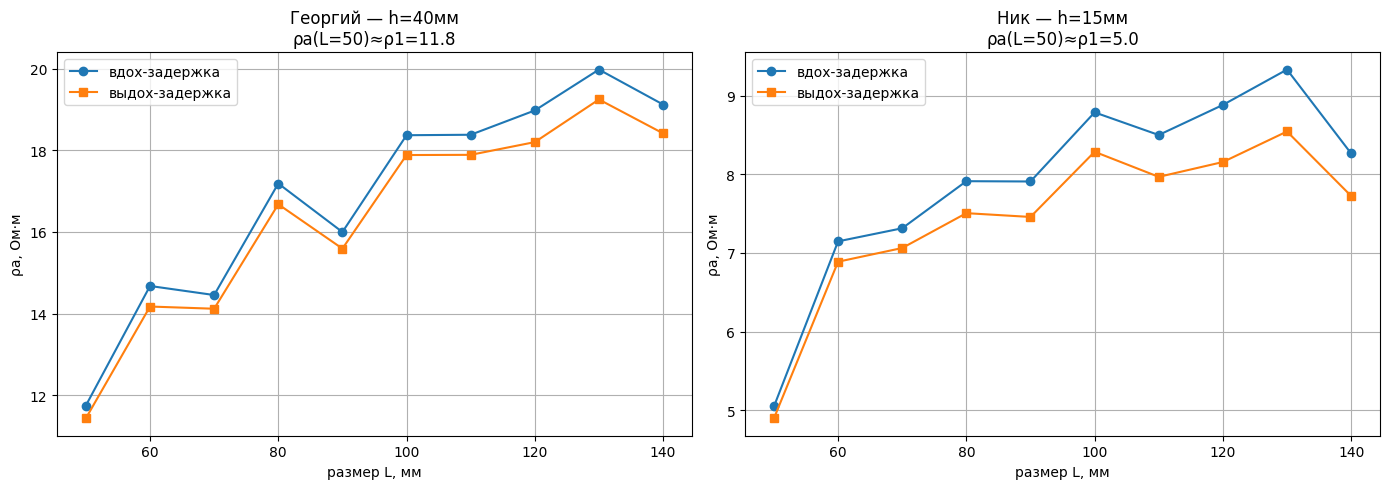

In [3]:
# @title График ρa(L)
fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 5), squeeze=False)
for j, (name, D) in enumerate(DATA.items()):
    Ls = D["sizes"]
    ra_in = [rho_app(D["Zin"][L], *ab(L)) for L in Ls]
    ra_ex = [rho_app(D["Zex"][L], *ab(L)) for L in Ls]
    a = ax[0][j]
    a.plot(Ls, ra_in, "o-", label="вдох-задержка")
    a.plot(Ls, ra_ex, "s-", label="выдох-задержка")
    a.set_title("%s — h=%dмм\nρa(L=50)≈ρ1=%.1f" % (name, int(D["h"]*1000), ra_in[0]))
    a.set_xlabel("размер L, мм"); a.set_ylabel("ρa, Ом·м"); a.legend(); a.grid(True)
plt.tight_layout(); plt.show()

## §3. Совместный МНК (ур. 12): ρ₁ общий, h фиксировано

Контрольный фит со свободным h показывает, какую «эффективную» глубину хочет форма кривой — сверка с h_КТ (§3.3).

In [4]:
# @title Совместный МНК (фикс-h и своб-h)
def joint_fit(D, free_h=False):
    Ls = D["sizes"]; h0 = D["h"]
    def resid(th):
        if free_h: r1, r2i, r2e, h = th
        else:      (r1, r2i, r2e), h = th, h0
        out = []
        for L in Ls:
            a, b = ab(L)
            out += [Z_model(r1, r2i, h, a, b)-D["Zin"][L], Z_model(r1, r2e, h, a, b)-D["Zex"][L]]
        return out
    if free_h:
        sol = least_squares(resid, [8, 22, 14, h0], bounds=([0.5,1,1,0.003],[60,200,200,0.10]))
        r1, r2i, r2e, h = sol.x
    else:
        sol = least_squares(resid, [8, 22, 14], bounds=([0.5,1,1],[60,200,200]))
        r1, r2i, r2e = sol.x; h = h0
    rms = np.sqrt(np.mean(np.array(sol.fun)**2))
    return dict(rho1=r1, rho2_in=r2i, rho2_ex=r2e, h=h, rms=rms)

print("%-8s | режим     | ρ1    ρ2вд   ρ2выд  Δρ2   h,мм | RMS,Ом" % "субъект")
print("-"*72)
for name, D in DATA.items():
    for free, tag in [(False, "фикс-h"), (True, "своб-h")]:
        f = joint_fit(D, free)
        D["fit"] = D.get("fit") or (f if not free else None)
        print("%-8s | %-9s | %4.2f  %5.2f  %5.2f  %4.2f  %4.1f | %5.2f"
              % (name, tag, f["rho1"], f["rho2_in"], f["rho2_ex"], f["rho2_in"]-f["rho2_ex"], f["h"]*1000, f["rms"]))
    D["fit"] = joint_fit(D, False)   # рабочая точка = фикс-h
print("\nρ2 — экстраполяция (§3.3): при толстых тканях слабо идентифицируема.")

# --- экспорт рабочей точки для 11 и 05 (поток данных пайплайна) ---
import os as _os, json as _json
_os.makedirs("params", exist_ok=True)
_json.dump({n: dict(rho1=D["fit"]["rho1"], rho2_in=D["fit"]["rho2_in"],
                    rho2_ex=D["fit"]["rho2_ex"], h=D["h"]) for n, D in DATA.items()},
           open(_os.path.join("params", "static.json"), "w", encoding="utf-8"),
           ensure_ascii=False, indent=1)
print("→ params/static.json записан")

субъект  | режим     | ρ1    ρ2вд   ρ2выд  Δρ2   h,мм | RMS,Ом
------------------------------------------------------------------------
Георгий  | фикс-h    | 13.21  200.00  200.00  0.00  40.0 | 15.10
Георгий  | своб-h    | 2.98  27.83  26.25  1.59   3.0 |  7.68
Ник      | фикс-h    | 4.73  17.74  14.76  2.98  15.0 |  7.02


Ник      | своб-h    | 1.41  13.00  11.73  1.27   3.0 |  5.94

ρ2 — экстраполяция (§3.3): при толстых тканях слабо идентифицируема.
→ params/static.json записан


## §4. Облако пересечений (ρ₁,ρ₂) и взвешенный центроид

Каждая пара решёток даёт точку пересечения кривых `Z=Z_k`. Невзвешенный центр масс смещён плохо обусловленными парами; корректный вес `w=sin²θ` между градиентами (ур. 6, 13).

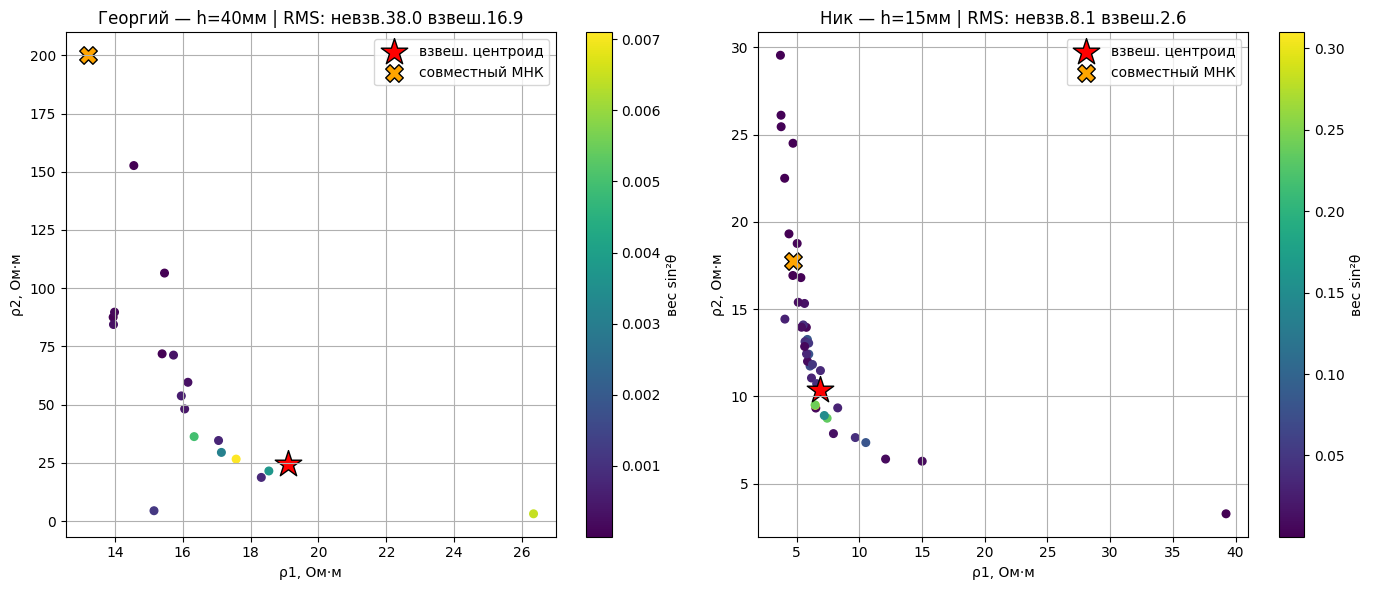

Взвешивание сжимает облако к консенсусу; RMS_невзв(Георг)/RMS_невзв(Ник) — мера ухудшения применимости.


In [5]:
# @title Пересечения, веса sin²θ, центроид (состояние = вдох)
def rho2_of(r1, L, Zt, h):
    a, b = ab(L); f = lambda r2: Z_model(r1, r2, h, a, b) - Zt
    try:
        if f(1)*f(200) > 0: return None
        return brentq(f, 1, 200)
    except Exception:
        return None

def intersections(D, Z):
    Ls = D["sizes"]; h = D["h"]; r1g = np.linspace(1, 40, 220); pts = []; ws = []
    for ii in range(len(Ls)):
        for jj in range(ii+1, len(Ls)):
            Li, Lj = Ls[ii], Ls[jj]
            xs = []
            for r1 in r1g:
                ai = rho2_of(r1, Li, Z[Li], h); aj = rho2_of(r1, Lj, Z[Lj], h)
                if ai is not None and aj is not None: xs.append((r1, ai-aj))
            for k in range(len(xs)-1):
                if xs[k][1]*xs[k+1][1] < 0:
                    r1c = xs[k][0] + (xs[k+1][0]-xs[k][0])*(-xs[k][1])/(xs[k+1][1]-xs[k][1])
                    r2c = rho2_of(r1c, Li, Z[Li], h)
                    if r2c is None: break
                    gi = np.array([dZ_drho1(r1c,r2c,h,*ab(Li)), dZ_drho2(r1c,r2c,h,*ab(Li))])
                    gj = np.array([dZ_drho1(r1c,r2c,h,*ab(Lj)), dZ_drho2(r1c,r2c,h,*ab(Lj))])
                    cs = np.dot(gi,gj)/(np.linalg.norm(gi)*np.linalg.norm(gj)+1e-12)
                    theta = np.arccos(np.clip(cs,-1,1))
                    pts.append((r1c, r2c)); ws.append(np.sin(theta)**2)
                    break
    return np.array(pts), np.array(ws)

fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 6), squeeze=False)
for j, (name, D) in enumerate(DATA.items()):
    pts, ws = intersections(D, D["Zin"]); a = ax[0][j]
    cen_u = pts.mean(0)
    cen_w = (pts*ws[:,None]).sum(0)/ws.sum()
    rms_u = np.sqrt(((pts-cen_u)**2).sum(1).mean())
    rms_w = np.sqrt((ws*((pts-cen_w)**2).sum(1)).sum()/ws.sum())
    D["cloud"] = dict(rms_u=rms_u, rms_w=rms_w, cen_w=cen_w, n=len(pts))
    sc = a.scatter(pts[:,0], pts[:,1], c=ws, cmap="viridis", s=30)
    a.scatter(*cen_w, marker="*", s=400, color="red", edgecolor="k", label="взвеш. центроид")
    a.scatter(D["fit"]["rho1"], D["fit"]["rho2_in"], marker="X", s=160, color="orange",
              edgecolor="k", label="совместный МНК")
    a.set_title("%s — h=%dмм | RMS: невзв.%.1f взвеш.%.1f" % (name, int(D["h"]*1000), rms_u, rms_w))
    a.set_xlabel("ρ1, Ом·м"); a.set_ylabel("ρ2, Ом·м"); a.legend(); a.grid(True)
    plt.colorbar(sc, ax=a, label="вес sin²θ")
plt.tight_layout(); plt.show()
print("Взвешивание сжимает облако к консенсусу; RMS_невзв(Георг)/RMS_невзв(Ник) — мера ухудшения применимости.")

### §4.1. Кривые решений (ρ₁,ρ₂) — перенесено из 07 §4

Каждая решётка задаёт кривую `Z(ρ₁,ρ₂)=Z_баз`; их пересечение = согласованное (ρ₁,ρ₂). Здесь — по плато задержек (строго), а не по медиане всей записи, как было в обзорном скетче 07.

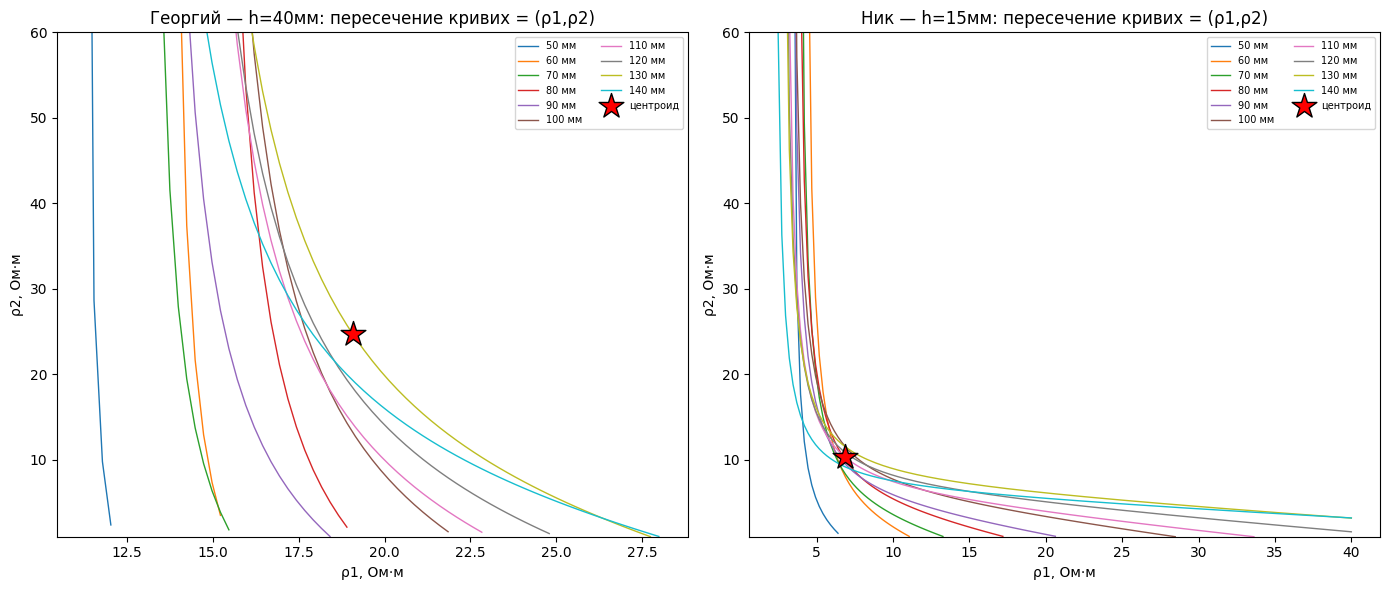

Где кривые сходятся — согласованные (ρ1,ρ2). Разброс схождения = облако §4.


In [6]:
# @title Кривые решений (ρ1,ρ2): каждая база = кривая, пересечение = (ρ1,ρ2)
r1grid = np.linspace(1, 40, 160)
fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 6), squeeze=False)
for j, (name, D) in enumerate(DATA.items()):
    a = ax[0][j]
    for L in D["sizes"]:
        xy = [(r1, rho2_of(r1, L, D["Zin"][L], D["h"])) for r1 in r1grid]
        xy = [(x, y) for x, y in xy if y is not None]
        if xy:
            xs, ys = zip(*xy); a.plot(xs, ys, lw=1, label="%d мм" % L)
    a.scatter(*D["cloud"]["cen_w"], marker="*", s=350, color="red", edgecolor="k", zorder=5, label="центроид")
    a.set_xlabel("ρ1, Ом·м"); a.set_ylabel("ρ2, Ом·м"); a.set_ylim(1, 60)
    a.set_title("%s — h=%dмм: пересечение кривих = (ρ1,ρ2)" % (name, int(D["h"]*1000)))
    a.legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()
print("Где кривые сходятся — согласованные (ρ1,ρ2). Разброс схождения = облако §4.")

## §5. Применимость: угловой спред градиентов и FoM (§2.4)

Чем у́же разброс направлений градиентов по решёткам, тем хуже обусловлены пересечения. Предсказание: у Георга (h=40) спред в разы у́же, чем у Ника (h=15).

In [7]:
# @title Угловой спред (общая раб. точка) и измеренное облако
# Спред считаем в ЕДИНОЙ физиологической точке, чтобы выделить эффект h,
# а не railed-ρ2 фита (у Георга ρ2 упирается в границу). Облако — измеренное.
OP_R1, OP_R2 = 8.0, 18.0
print("%-8s | спред углов градиента @(ρ1=%.0f,ρ2=%.0f) | RMS_невзв облака | отнош. к Нику"
      % ("субъект", OP_R1, OP_R2))
print("-"*78)
rows = []
for name, D in DATA.items():
    h = D["h"]
    angs = [np.degrees(np.arctan2(dZ_drho2(OP_R1,OP_R2,h,*ab(L)), dZ_drho1(OP_R1,OP_R2,h,*ab(L)))) for L in D["sizes"]]
    rows.append((name, max(angs)-min(angs), D["cloud"]["rms_u"]))
nik = next((r for r in rows if r[0] == "Ник"), rows[0])
for name, spread, rms in rows:
    print("%-8s | %5.1f°                             | %7.2f          | ×%.2f"
          % (name, spread, rms, rms/nik[2]))
print("\nУзкий спред (толстые ткани) -> почти параллельные кривые -> широкое облако (ур. 6):")
print("теория (спред) и эксперимент (RMS облака) дают одинаковую упорядоченность Ник < Георгий.")

субъект  | спред углов градиента @(ρ1=8,ρ2=18) | RMS_невзв облака | отнош. к Нику
------------------------------------------------------------------------------
Георгий  |   5.1°                             |   37.97          | ×4.69
Ник      |  21.4°                             |    8.09          | ×1.00

Узкий спред (толстые ткани) -> почти параллельные кривые -> широкое облако (ур. 6):
теория (спред) и эксперимент (RMS облака) дают одинаковую упорядоченность Ник < Георгий.


## §5.1. Систолические Δρ₁, Δρ₂ тем же методом (пересечение прямых)

Для статики каждая решётка давала **кривую** Z(ρ₁,ρ₂)=Z_баз (§4). Для систолы изменения малы → связь линейна: `∂Z/∂ρ₁·Δρ₁ + ∂Z/∂ρ₂·Δρ₂ = ΔZ_сист(L)`, и каждая решётка даёт **прямую** в плоскости (Δρ₁,Δρ₂). Пересечение прямых = (Δρ₁,Δρ₂); облако пересечений и взвешенный центроид анализируем так же, как для ρ. ΔZ_сист берём из реограммы `RHEO_2` (ансамбль по R-зубцам из меток). Производные считаем в рабочей точке: ρ₁ из фита, ρ₂ из КТ (`params/ct.json`).

субъект  | взвеш. центроид (Δρ1, Δρ2), мОм·м | разброс Δρ1 / Δρ2
------------------------------------------------------------------------


Георгий  | (+2.1, +66.9)               | ±2.0 / ±19.9


Ник      | (-1.7, +82.7)               | ±2.2 / ±16.6


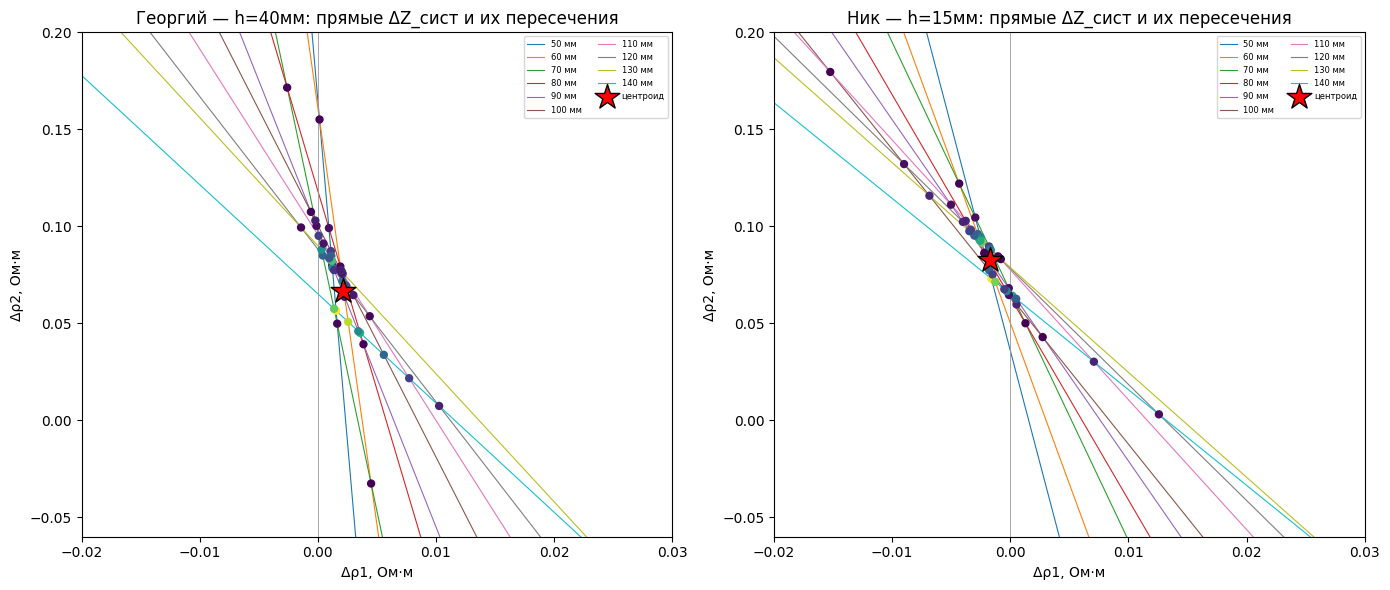

Δρ2 ≈ +0.08 Ом·м (значение ≫ разброса → определён: кровенаполнение лёгкого).
Δρ1 ≈ ±0.002 Ом·м при разбросе ±0.002 и разном знаке у испытуемых → не отличим от нуля (граница, §4.8 док.06).


In [8]:
# @title Систолические Δρ1,Δρ2: прямые j1·Δρ1+j2·Δρ2=ΔZ_сист, пересечение, облако
import pandas as pd
ROOT_EXP = r"Z:\01 Project\01 Experiments\EXP_2026_04_29_BMSTU_REOCARDIO_GEORG_NIX"
DIRS = {"Ник": (os.path.join(ROOT_EXP, "2026-04-29 Николай Калмыков"), "nik"),
        "Георгий": (os.path.join(ROOT_EXP, "2026-04-29 Георгий Плыткевич"), "georg")}
RAIL, PRE, POST = 502.8, 0.15, 0.70
_ctp = os.path.join("params", "ct.json")
_ct = json.load(open(_ctp, encoding="utf-8")) if os.path.exists(_ctp) else {}

def dZ_sist(name, L):
    d, pat = DIRS[name]
    df = pd.read_csv(os.path.join(d, "%d%s.csv" % (L, pat)), encoding="utf-8")
    t = df["TIME_s"].values; fs = 1.0/np.median(np.diff(t))
    R = np.array(json.load(open(os.path.join(TS_DIR, "%d%s.json" % (L, pat)), encoding="utf-8"))["rpeaks_s"])
    x = df["RHEO_2_mΩ"].values; ip, ipo = int(PRE*fs), int(POST*fs); segs = []
    for r in R:
        i = int(r*fs)
        if i-ip >= 0 and i+ipo < len(x):
            s = x[i-ip:i+ipo]
            if np.mean(np.abs(np.abs(s)-RAIL) < 0.5) > 0.02: continue
            segs.append(s)
    a = np.array(segs).mean(0); return (a.max()-a.min())/1000.0   # Ом

fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 6), squeeze=False)
print("%-8s | взвеш. центроид (Δρ1, Δρ2), мОм·м | разброс Δρ1 / Δρ2" % "субъект")
print("-"*72)
for jx, (name, D) in enumerate(DATA.items()):
    r1 = D["fit"]["rho1"]; r2 = _ct.get(name, {}).get("rho2_ct") or D["fit"]["rho2_in"]; h = D["h"]
    Ls = D["sizes"]
    lines = [(dZ_drho1(r1, r2, h, *ab(L)), dZ_drho2(r1, r2, h, *ab(L)), dZ_sist(name, L)) for L in Ls]
    pts, ws = [], []
    for i in range(len(Ls)):
        for k in range(i+1, len(Ls)):
            a1, b1, c1 = lines[i]; a2, b2, c2 = lines[k]; det = a1*b2 - b1*a2
            if abs(det) < 1e-12: continue
            x = (c1*b2 - b1*c2)/det; y = (a1*c2 - c1*a2)/det
            ws.append((abs(det)/(np.hypot(a1, b1)*np.hypot(a2, b2)))**2); pts.append((x, y))
    pts = np.array(pts); ws = np.array(ws)
    cw = (pts*ws[:, None]).sum(0)/ws.sum()
    sd1 = np.sqrt((ws*(pts[:, 0]-cw[0])**2).sum()/ws.sum())
    sd2 = np.sqrt((ws*(pts[:, 1]-cw[1])**2).sum()/ws.sum())
    print("%-8s | (%+.1f, %+.1f)               | ±%.1f / ±%.1f" % (name, cw[0]*1000, cw[1]*1000, sd1*1000, sd2*1000))
    a = ax[0][jx]; xx = np.linspace(-0.02, 0.03, 50)
    for (j1, j2, c), L in zip(lines, Ls):
        if abs(j2) > 1e-9: a.plot(xx, (c - j1*xx)/j2, lw=0.8, label="%d мм" % L)
    a.scatter(pts[:, 0], pts[:, 1], c=ws, cmap="viridis", s=25, zorder=4)
    a.scatter(*cw, marker="*", s=350, color="red", edgecolor="k", zorder=5, label="центроид")
    a.axvline(0, color="0.6", lw=0.6)
    a.set_xlim(-0.02, 0.03); a.set_ylim(-0.06, 0.20)
    a.set_xlabel("Δρ1, Ом·м"); a.set_ylabel("Δρ2, Ом·м")
    a.set_title("%s — h=%dмм: прямые ΔZ_сист и их пересечения" % (name, int(h*1000)))
    a.legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()
print("Δρ2 ≈ +0.08 Ом·м (значение ≫ разброса → определён: кровенаполнение лёгкого).")
print("Δρ1 ≈ ±0.002 Ом·м при разбросе ±0.002 и разном знаке у испытуемых → не отличим от нуля (граница, §4.8 док.06).")

### §5.2. Δρ из непульсового канала BASE (задержка вдоха) — проверка согласованности каналов

ρ₁,ρ₂ взяты из **BASE** (статический канал, реальные омы), а Δρ §5.1 — из **RHEO** (пульсовой). Для согласованности считаем Δρ и из **BASE** на задержке вдоха: сердечный размах `BASE_2`, ансамбль по R-зубцам, тот же метод облака прямых. Это заодно проверка калибровки RHEO (BASE — в реальных Ом). ⚠ Сигнал BASE на плато слабый (мало ударов, низкая когерентность).

субъект  | BASE-облако (Δρ1,Δρ2) мОм·м | RHEO Δρ2 | ΔZ_base тренд по L | когер.
------------------------------------------------------------------------------------------


Георгий  | (+4.3, +3.0)             | +96.0     | растёт→ρ2 | 0.1


Ник      | (+1.6, -0.4)             | +65.3     | падает→ρ1 | 0.2


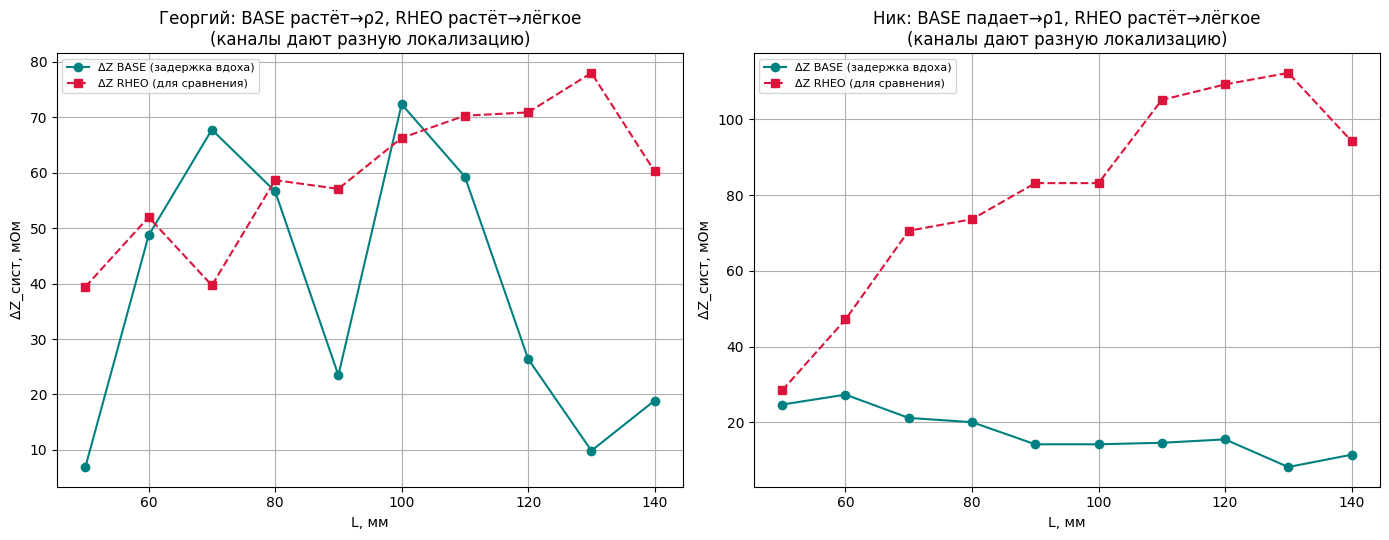

ВЫВОД: BASE и RHEO НЕ согласованы — у Ника BASE убывает с L (как ρ1), RHEO растёт (как ρ2).
Отношение RHEO/BASE непостоянно (1.5–13×) -> RHEO не просто усиленный BASE (вероятно dZ/dt).
Следствие: абсолютную систолическую шкалу Δρ нельзя доверять без КАЛИБРОВКИ RHEO (откр. вопрос §4.8).


In [9]:
# @title Δρ из BASE на задержке вдоха + сравнение каналов BASE vs RHEO
def dZ_base(name, L):
    d, pat = DIRS[name]
    df = pd.read_csv(os.path.join(d, "%d%s.csv" % (L, pat)), encoding="utf-8")
    t = df["TIME_s"].values; fs = 1.0/np.median(np.diff(t))
    rec = json.load(open(os.path.join(TS_DIR, "%d%s.json" % (L, pat)), encoding="utf-8"))
    t0, t1 = rec["modes"]["задержка_вдох"]
    R = [r for r in rec["rpeaks_s"] if t0+0.5 <= r <= t1-0.5]
    ip, ipo = int(0.15*fs), int(0.6*fs); x = df["BASE_2_Ω"].values; segs = []
    for r in R:
        i = int(r*fs)
        if i-ip >= 0 and i+ipo < len(x): segs.append(x[i-ip:i+ipo])
    segs = np.array(segs); avg = segs.mean(0)
    amp = avg.max()-avg.min(); coh = amp/(segs.std(0).mean()+1e-9)  # когерентность ансамбля
    return amp, coh

fig, ax = plt.subplots(1, len(DATA), figsize=(7*len(DATA), 5.5), squeeze=False)
print("%-8s | BASE-облако (Δρ1,Δρ2) мОм·м | RHEO Δρ2 | ΔZ_base тренд по L | когер." % "субъект")
print("-"*90)
for jx, (name, D) in enumerate(DATA.items()):
    r1 = D["fit"]["rho1"]; r2 = _ct.get(name, {}).get("rho2_ct") or D["fit"]["rho2_in"]; h = D["h"]
    Ls = D["sizes"]
    base = [dZ_base(name, L) for L in Ls]; cZ = [b[0] for b in base]; coh = np.mean([b[1] for b in base])
    rZ = [dZ_sist(name, L) for L in Ls]   # RHEO (из §5.1)
    lines = [(dZ_drho1(r1,r2,h,*ab(L)), dZ_drho2(r1,r2,h,*ab(L)), cZ[k]) for k,L in enumerate(Ls)]
    pts, ws = [], []
    for i in range(len(Ls)):
        for k in range(i+1, len(Ls)):
            a1,b1,c1=lines[i]; a2,b2,c2=lines[k]; det=a1*b2-b1*a2
            if abs(det)<1e-12: continue
            x=(c1*b2-b1*c2)/det; y=(a1*c2-c1*a2)/det
            ws.append((abs(det)/(np.hypot(a1,b1)*np.hypot(a2,b2)))**2); pts.append((x,y))
    pts=np.array(pts); ws=np.array(ws); cw=(pts*ws[:,None]).sum(0)/ws.sum()
    trend = "растёт→ρ2" if cZ[-1] > cZ[0] else "падает→ρ1"
    print("%-8s | (%+.1f, %+.1f)             | %+.1f     | %s | %.1f"
          % (name, cw[0]*1000, cw[1]*1000, np.median(rZ)/np.median([dZ_drho2(r1,r2,h,*ab(L)) for L in Ls])*1000, trend, coh))
    a = ax[0][jx]
    a.plot(Ls, np.array(cZ)*1000, "o-", color="teal", label="ΔZ BASE (задержка вдоха)")
    a.plot(Ls, np.array(rZ)*1000, "s--", color="crimson", label="ΔZ RHEO (для сравнения)")
    a.set_xlabel("L, мм"); a.set_ylabel("ΔZ_сист, мОм")
    a.set_title("%s: BASE %s, RHEO растёт→лёгкое\n(каналы дают разную локализацию)" % (name, trend))
    a.legend(fontsize=8); a.grid(True)
plt.tight_layout(); plt.show()
print("ВЫВОД: BASE и RHEO НЕ согласованы — у Ника BASE убывает с L (как ρ1), RHEO растёт (как ρ2).")
print("Отношение RHEO/BASE непостоянно (1.5–13×) -> RHEO не просто усиленный BASE (вероятно dZ/dt).")
print("Следствие: абсолютную систолическую шкалу Δρ нельзя доверять без КАЛИБРОВКИ RHEO (откр. вопрос §4.8).")

## §6. Выводы

- ρ₁ восстанавливается надёжно из мелкого конца (ρₐ при L=50): тонкие ткани → низкое ρ₁, толстые → высокое — согласуется с h_КТ.
- ρ₂ — экстраполяция; при толстых тканях (Георгий) почти неидентифицируема, облако пересечений в разы шире → **двуслойная модель применима ограниченно** (количественно, через §2.4).
- Различие вдох/выдох устойчиво на каждом размере, даже когда абсолютное ρ₂ шатко (§3.3).
- Следующий шаг — атрибуция причины (обусловленность vs нарушение плоскостности) через КТ/МКЭ (§2.5) и сверка ρ₂, h с КТ (§3).